In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
train = pd.read_csv('../data/raw/train.csv')
display(train.shape)
train.head()

(7613, 5)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [6]:
test = pd.read_csv('../data/raw/test.csv')
display(test.shape)
test.head()

(3263, 4)

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [9]:
train.target.value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

In [10]:
train.keyword.value_counts()

keyword
fatalities               45
armageddon               42
deluge                   42
body%20bags              41
damage                   41
                         ..
forest%20fire            19
epicentre                12
threat                   11
inundation               10
radiation%20emergency     9
Name: count, Length: 221, dtype: int64

In [11]:
# жесткий текст ...
train[train.target == 1]["text"][0]

'Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all'

In [12]:
train.location.value_counts()

location
USA                       104
New York                   71
United States              50
London                     45
Canada                     29
                         ... 
TN                          1
#NewcastleuponTyne #UK      1
Vancouver, Canada           1
London                      1
Lincoln                     1
Name: count, Length: 3341, dtype: int64

In [13]:
train.drop_duplicates(subset="text", keep="first").shape, train.shape

((7503, 5), (7613, 5))

In [14]:
test.drop_duplicates(subset="text", keep="first").shape, test.shape

((3243, 4), (3263, 4))

In [15]:
conflict_mask = train.groupby("text")["target"].transform("nunique") > 1
train[conflict_mask].shape

(55, 5)

In [16]:
0.1/ 0.2

0.5

<Axes: >

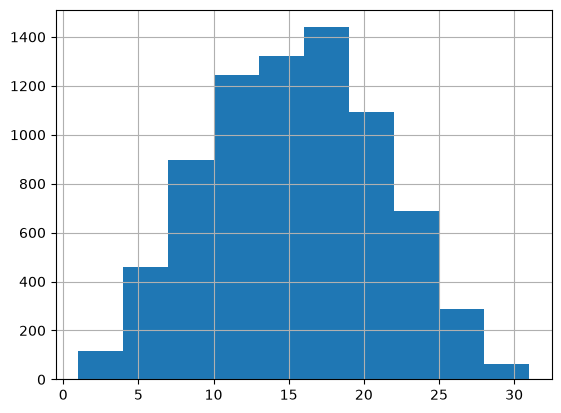

In [17]:
train["len_text"] = train["text"].str.split().str.len()
train["len_text"].hist()

# Выводы

1. Дисбаланса таргета нет
2. Локейшен и кейвордс выглядят достаточно информативными, можно их использовать в обучении, обработав пропуски
3. В трейне есть дубли по тексту - удалить повторы 
4. Есть дубли с разным таргетом - удалить такие объекты полностью


In [18]:
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize


STOP_WORDS = set(stopwords.words("english"))

STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
WORD_PATTERN = re.compile(r"^[a-z]+$")

def proccessing_data(df: pd.DataFrame) -> pd.DataFrame:
 ... продолжи
def duplicates_processing(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    conflict_mask = df.groupby("text")["target"].transform("nunique") > 1

    df = (
        df[~conflict_mask]
        .drop_duplicates(subset="text", keep="first")
        .reset_index(drop=True)
    )
    return df

def filtering(
    text: str,
) -> str:
    text = URL_PATTERN.sub(" ", text)
    text = MENTION_PATTERN.sub(" ", text)
    text = HASHTAG_PATTERN.sub(r"\1", text)    
    return text

def preprocessing_text(
    text: str,
    *,
    lower = True,
    filtering = True,
    remove_stopwords: bool = False,
    normalization: str = "none",
) -> str:
    """Preprocess a single tweet."""
    if lower:
        text = text.lower()
        
    if filtering:
        text = filtering(text)

    tokens = word_tokenize(text)

    tokens = [
        token
        for token in tokens
        if WORD_PATTERN.fullmatch(token)
    ]

    if remove_stopwords:
        tokens = [
            token
            for token in tokens
            if token not in STOP_WORDS
        ]

    if normalization == "lemma":
        tokens = [
            LEMMATIZER.lemmatize(token)
            for token in tokens
        ]
    elif normalization == "stem":
        tokens = [
            STEMMER.stem(token)
            for token in tokens
        ]
    elif normalization != "none":
        raise ValueError(
            f"Unknown normalization: {normalization}"
        )

    return " ".join(tokens)


SyntaxError: invalid syntax (1735016707.py, line 19)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
)
from sklearn.model_selection import train_test_split

from src.data.loader import load_raw
from src.preprocessing.preprocessing import preprocess_dataframe


RANDOM_STATE = 42

pp_cfg = {
    "filtering": {
        "lower": True,
        "remove_url": True,
        "remove_mentions": True,
        "remove_hashtags_symbol": True,
        "keep_only_alpha": True,
        "min_token_len": 2,
    },
    "stopwords": {"enabled": True, "language": "english"},
    "normalization": "lemma",
    "duplicates": {"mode": "drop_conflict", "text_col": "text", "target_col": "target"},
    "columns": {"text": "text", "out": "text_pp"},
    "drop_empty": True,
}

df = preprocess_dataframe(train, pp_cfg=pp_cfg)
print("after preprocess:", df.shape)
df[["text", "text_pp", "target"]].head()

[preproc] drop_conflict: 7613 -> 7485
[preproc] dropped 2 empty-after-preprocess rows
after preprocess: (7483, 6)


,text,text_pp,target
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive u,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...,1
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...,1
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...,1


In [ ]:
train_pp, temp_pp = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)
val_pp, test_pp = train_test_split(
    temp_pp,
    test_size=0.5,
    stratify=temp_pp["target"],
    random_state=RANDOM_STATE,
)

print(f"train={len(train_pp)}, val={len(val_pp)}, test={len(test_pp)}")
print(f"target rate train={train_pp.target.mean():.4f}  val={val_pp.target.mean():.4f}  test={test_pp.target.mean():.4f}")

train=5986, val=748, test=749
target rate train=0.4258  val=0.4265  test=0.4259


In [ ]:
df

,id,keyword,location,text,target,text_pp
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,deed reason earthquake may allah forgive u
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,resident asked shelter place notified officer ...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,people receive wildfire evacuation order calif...
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,got sent photo ruby alaska smoke wildfire pour...
...,...,...,...,...,...,...
7478,10863,NaN,NaN,#WorldNews Fallen powerlines on G:link tram: U...,1,worldnews fallen powerlines link tram update f...
7479,10864,NaN,NaN,on the flip side I'm at Walmart and there is a...,1,flip side walmart bomb everyone evacuate stay ...
7480,10866,NaN,NaN,Suicide bomber kills 15 in Saudi security site...,1,suicide bomber kill saudi security site mosque...
7481,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1,two giant crane holding bridge collapse nearby...


In [19]:
train_pp, temp_pp = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)
val_pp, test_pp = train_test_split(
    temp_pp,
    test_size=0.5,
    stratify=temp_pp["target"],
    random_state=RANDOM_STATE,
)

print(f"train={len(train_pp)}, val={len(val_pp)}, test={len(test_pp)}")
print(f"target rate train={train_pp.target.mean():.4f}  val={val_pp.target.mean():.4f}  test={test_pp.target.mean():.4f}")

train=5986, val=748, test=749
target rate train=0.4258  val=0.4265  test=0.4259


In [22]:
train_pp

,id,keyword,location,text,target,text_pp
6039,8774,siren,Diamondville,Look at them'@Ayhoka_: Co happy bn too long'@F...,0,look co happy bn long oh finally jennifer anis...
1756,2555,crash,NaN,MotoGP Indianapolis: Espargaro: Layout 'worrie...,0,motogp indianapolis espargaro layout worry little
5388,7830,quarantine,"NYC, New York",Reddit Will Now Quarantine Offensive Content: ...,0,reddit quarantine offensive content reddit ceo...
2173,3147,debris,NaN,MH370: Aircraft debris found on La Reunion is ...,1,aircraft debris found la reunion missing malay...
4052,5849,hailstorm,"Suginami-ku, Tokyo, Japan",Severe weather and a rare hailstorm pummel Bos...,1,severe weather rare hailstorm pummel boston
...,...,...,...,...,...,...
379,552,arson,"Charlotte, NC",Add Familia to the arson squad.,0,add familia arson squad
174,254,ambulance,Happily Married with 2 kids,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...,0,ambulance sprinter automatic frontline vehicle...
7075,10313,weapon,NaN,Back to back like I'm on the cover of lethal w...,0,back back like cover lethal weapon
1536,2250,chemical%20emergency,"Mankato, MN",Emergency responders prepare for chemical disa...,1,emergency responder prepare chemical disaster ...


In [20]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
)

X_train = vectorizer.fit_transform(train_pp["text_pp"])
X_val   = vectorizer.transform(val_pp["text_pp"])
X_test  = vectorizer.transform(test_pp["text_pp"])

y_train = train_pp["target"].values
y_val   = val_pp["target"].values
y_test  = test_pp["target"].values

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

X_train: (5986, 8249) X_val: (748, 8249) X_test: (749, 8249)


In [24]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 55226 stored elements and shape (5986, 8249)>

In [21]:
model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

def evaluate(model, X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "split": name,
        "accuracy":  accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall":    recall_score(y, pred),
        "f1":        f1_score(y, pred),
        "roc_auc":   roc_auc_score(y, proba),
    }

metrics = pd.DataFrame([
    evaluate(model, X_train, y_train, "train"),
    evaluate(model, X_val,   y_val,   "val"),
    evaluate(model, X_test,  y_test,  "test"),
])
metrics

,split,accuracy,precision,recall,f1,roc_auc
0,train,0.886067,0.941371,0.781091,0.853774,0.955831
1,val,0.791444,0.824701,0.648903,0.726316,0.852453
2,test,0.778371,0.797665,0.642633,0.711806,0.845054


In [25]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.model_selection import train_test_split

from src.data.loader import load_raw
from src.data.split import stratified_split
from src.preprocessing.preprocessing import preprocess_dataframe
from src.features.builder import build_features
from src.features.categorical import CategoricalEncoder, MISSING, RARE

In [26]:
pp_cfg = {
    "filtering": {
        "lower": True,
        "remove_url": True,
        "remove_mentions": True,
        "remove_hashtags_symbol": True,
        "keep_only_alpha": True,
        "min_token_len": 2,
    },
    "stopwords": {"enabled": True, "language": "english"},
    "normalization": "lemma",
    "duplicates": {"mode": "drop_conflict", "text_col": "text", "target_col": "target"},
    "columns": {"text": "text", "out": "text_pp"},
    "drop_empty": True,
}

df = preprocess_dataframe(train , pp_cfg=pp_cfg)
print("after preprocess:", df.shape)
df[["text", "text_pp", "keyword", "location", "target"]].head(3)

split_cfg = {"val_size": 0.1, "test_size": 0.1, "seed": 42, "stratify_col": "target"}
tr, va, te = stratified_split(
    df,
    target_col=split_cfg["stratify_col"],
    val_size=split_cfg["val_size"],
    test_size=split_cfg["test_size"],
    seed=split_cfg["seed"],
)
print(len(tr), len(va), len(te))
print("target rates:", tr.target.mean(), va.target.mean(), te.target.mean())


enc = CategoricalEncoder(normalize=True, min_freq=5).fit(tr["location"])
print("n_features location:", enc.n_features)

# посмотрим, во что превращается пара значений
sample = pd.Series(["New York, USA", "nyc", None, "  ", "Some Rare Place 123"])
print("normalized + collapsed sample:")
from src.features.categorical import _normalize_series
print(_normalize_series(sample, True).tolist())

[preproc] drop_conflict: 7613 -> 7485
[preproc] dropped 2 empty-after-preprocess rows
after preprocess: (7483, 7)
5986 748 749
target rates: 0.4258269295021717 0.4264705882352941 0.4259012016021362
n_features location: 95
normalized + collapsed sample:
['new york, usa', 'nyc', '__missing__', '__missing__', 'some rare place 123']


In [28]:
features_cfg = {
    "text": {
        "type": "tfidf",
        "column": "text_pp",
        "params": {
            "max_features": 50000,
            "ngram_range": (1, 2),
            "sublinear_tf": True,
            "min_df": 2,
        },
    },
    "keyword": {
        "type": "onehot",
        "column": "keyword",
        "normalize": True,
        "min_freq": 2,
        "handle_missing": "__missing__",
        "handle_unknown": "__rare__",
    },
    "location": {
        "type": "onehot",
        "column": "location",
        "normalize": True,
        "min_freq": 5,
        "handle_missing": "__missing__",
        "handle_unknown": "__rare__",
    },
}

bundle = build_features(tr, va, te, features_cfg)
print("blocks:", bundle.blocks)
print("X shapes:", bundle.X_train.shape, bundle.X_val.shape, bundle.X_test.shape)
print("n_features:", bundle.n_features)

blocks: ['text', 'keyword', 'location']
X shapes: (5986, 8566) (748, 8566) (749, 8566)
n_features: 8566


In [29]:
X = bundle.X_train
print("type:", type(X).__name__, "dtype:", X.dtype)
print("nnz:", X.nnz, "density:", X.nnz / (X.shape[0] * X.shape[1]))

# первые 5 элементов в первой строке
row0 = X[0]
print("row0 nnz:", row0.nnz)
print("row0 nonzero idx:", row0.indices[:10])

type: csr_matrix dtype: float64
nnz: 67198 density: 0.0013105136984351143
row0 nnz: 19
row0 nonzero idx: [4278 1351 3233  780 4268 5116 2625 3819  248 3087]


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
clf.fit(bundle.X_train, tr["target"].values)

val_pred = clf.predict(bundle.X_val)
val_proba = clf.predict_proba(bundle.X_val)[:, 1]
print("val f1 :", f1_score(va["target"], val_pred))
print("val auc:", roc_auc_score(va["target"], val_proba))

val f1 : 0.7445742904841403
val auc: 0.8471403204945525


In [ ]:
test builder 

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from src.data.loader import load_raw
from src.data.split import stratified_split
from src.preprocessing.preprocessing import preprocess_dataframe
from src.features.builder import build_features

train_df, _ = load_raw()

pp_cfg = {
    "filtering": {"lower": True, "remove_url": True, "remove_mentions": True,
                  "remove_hashtags_symbol": True, "keep_only_alpha": True, "min_token_len": 2},
    "stopwords": {"enabled": True, "language": "english"},
    "normalization": "lemma",
    "duplicates": {"mode": "drop_conflict", "text_col": "text", "target_col": "target"},
    "columns": {"text": "text", "out": "text_pp"},
    "drop_empty": True,
}
df = preprocess_dataframe(train_df, pp_cfg=pp_cfg)
tr, va, te = stratified_split(df, target_col="target", val_size=0.1, test_size=0.1, seed=42)
print("splits:", len(tr), len(va), len(te))

sparse_tfidf = {
    "builder_output": "sparse",
    "text":     {"type": "tfidf", "column": "text_pp",
                 "params": {"max_features": 50000, "ngram_range": (1,2), "sublinear_tf": True, "min_df": 2}},
    "keyword":  {"type": "onehot", "column": "keyword", "normalize": True, "min_freq": 2},
    "location": {"type": "onehot", "column": "location", "normalize": True, "min_freq": 5},
}

sparse_w2v = {
    "builder_output": "sparse",
    "text":     {"type": "word2vec", "column": "text_pp",
                 "params": {"vector_size": 100, "window": 5, "min_count": 2, "epochs": 10, "seed": 42}},
    "keyword":  {"type": "onehot", "column": "keyword", "normalize": True, "min_freq": 2},
    "location": {"type": "onehot", "column": "location", "normalize": True, "min_freq": 5},
}

df_mode = {
    "builder_output": "dataframe",
    "text":     {"type": "none", "column": "text_pp"},
    "keyword":  {"type": "none", "column": "keyword"},
    "location": {"type": "none", "column": "location"},
}

bad = {
    "df_tfidf":    {**df_mode, "text": {"type": "tfidf", "column": "text_pp"}},
    "df_onehot":   {**df_mode, "keyword": {"type": "onehot", "column": "keyword"}},
    "df_w2v":      {**df_mode, "text": {"type": "word2vec", "column": "text_pp", "params": {"vector_size": 50}}},
    "sparse_none": {"builder_output": "sparse",
                    "text": {"type": "none", "column": "text_pp"},
                    "keyword": {"type": "onehot", "column": "keyword"},
                    "location": {"type": "onehot", "column": "location"}},
    "bad_output":  {"builder_output": "numpy",
                    "text": {"type": "tfidf", "column": "text_pp"},
                    "keyword": {"type": "none"}, "location": {"type": "none"}},
}

b1 = build_features(tr, va, te, sparse_tfidf)
b2 = build_features(tr, va, te, sparse_w2v)
b3 = build_features(tr, va, te, df_mode)

print("\n-- sparse tfidf --")
print("output:", b1.output, "| blocks:", b1.blocks, "| n_features:", b1.n_features)
print("shapes:", b1.X_train.shape, b1.X_val.shape, b1.X_test.shape, "| type:", type(b1.X_train).__name__)
print("nnz:", b1.X_train.nnz)

print("\n-- sparse w2v --")
print("blocks:", b2.blocks, "| n_features:", b2.n_features, "| shape:", b2.X_train.shape)

print("\n-- dataframe --")
print("output:", b3.output, "| blocks:", b3.blocks, "| shape:", b3.df_train.shape)
print("columns:", list(b3.df_train.columns))
print("dtypes:\n", b3.df_train.dtypes)
print(b3.df_train.head(3))

print("\n-- negative cases --")
for name, cfg in bad.items():
    try:
        build_features(tr, va, te, cfg)
        print(f"{name}: NO ERROR (BUG)")
    except (ValueError, TypeError) as e:
        print(f"{name}: {type(e).__name__}: {str(e)[:100]}")

[preproc] drop_conflict: 7613 -> 7485
[preproc] dropped 2 empty-after-preprocess rows
splits: 5986 748 749

-- sparse tfidf --
output: sparse | blocks: ['text', 'keyword', 'location'] | n_features: 8566
shapes: (5986, 8566) (748, 8566) (749, 8566) | type: csr_matrix
nnz: 67198

-- sparse w2v --
blocks: ['text', 'keyword', 'location'] | n_features: 417 | shape: (5986, 417)

-- dataframe --
output: dataframe | blocks: ['text', 'keyword', 'location'] | shape: (5986, 3)
columns: ['text_pp', 'keyword', 'location']
dtypes:
 text_pp     str
keyword     str
location    str
dtype: object
                                             text_pp     keyword  \
0  look co happy bn long oh finally jennifer anis...       siren   
1  motogp indianapolis espargaro layout worry little       crash   
2  reddit quarantine offensive content reddit ceo...  quarantine   

        location  
0   Diamondville  
1            NaN  
2  NYC, New York  

-- negative cases --
df_tfidf: ValueError: builder_output='dataf